In [1]:
#------------------------------DO NOT EDIT THE BELOW CODE--------------------------------------------#
#--------------THIS PART OF CODE WILL BE USED TO LATER EVALUATE THE SUBMITTED ASSIGNMENT--------------#
import sys
if len(sys.argv) != 2:
    print("Usage: python your_program.py <filename>")
    sys.exit(1)
file = sys.argv[1]

In [ ]:
file = "filepath to .h5 file"  #put the path of the downloaded h5 file which was assigned to your team

#------------------------------DO NOT EDIT THE BELOW CODE--------------------------------------------#
import h5py
import numpy as np
with h5py.File(file, "r") as hf:
    trace_array = np.array(hf["trace_array"])
    textin_array = np.array(hf["textin_array"])
    textout_array = np.array(hf["textout_array"])
    key_array = np.array(hf["key_array"])

sbox = [
    # 0    1    2    3    4    5    6    7    8    9    a    b    c    d    e    f 
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76, # 0
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0, # 1
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15, # 2
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75, # 3
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84, # 4
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf, # 5
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8, # 6
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2, # 7
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73, # 8
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb, # 9
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79, # a
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08, # b
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a, # c
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e, # d
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf, # e
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16  # f
]
print(trace_array.shape)
print('plaintext:',textin_array[0])
print('actual key:',key_array[0])
print('ciphertext:',textout_array[0])

(50, 5250)
plaintext: [153  86   0 142 162 248  37 253   2 143 137  28 241 231 130 105]
actual key: [ 24 111 181 111 233  50 246 104   1 132   6 120 225  63  74 150]
ciphertext: [115 248 110  95 103 198 119  97 218 220 243 200 253 250  52 195]


## Our Changes

#### Initial Plots

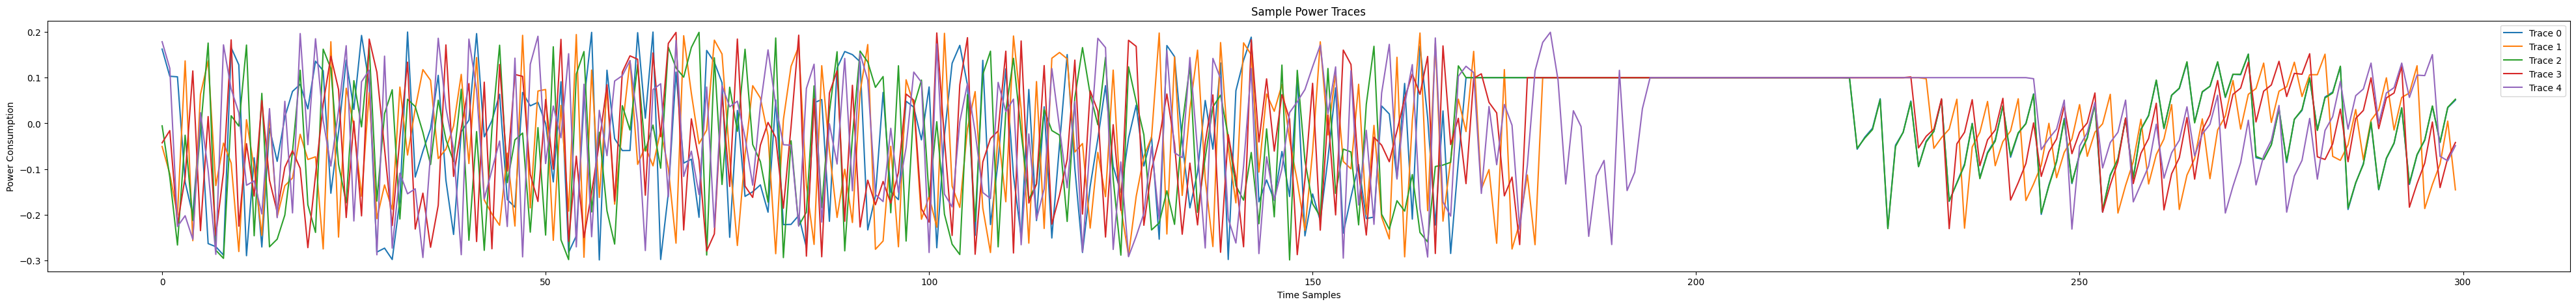

In [68]:
import matplotlib.pyplot as plt
plt.figure(figsize=(50, 5))
num_samples_to_plot = 5  # Change this to plot more traces

for i in range(num_samples_to_plot):
    plt.plot(trace_array[i][:300], label=f"Trace {i}")

plt.xlabel("Time Samples")
plt.ylabel("Power Consumption")
plt.title("Sample Power Traces")
plt.legend()
plt.show()


#### Algorithm

In [ ]:

def getCorrelation(hPower, trace):

    meanH = np.mean(hPower, axis=0)
    meanTrace = np.mean(trace, axis=0)

    mat1 = hPower - meanH[np.newaxis, :]
    mat2 = trace - meanTrace[np.newaxis, :]

    numerator = np.sum(mat1[:, :, np.newaxis] * mat2[:, np.newaxis, :], axis=0)
    # print(mat1.shape)
    denominator = np.sum(mat1**2, axis=0)[:, np.newaxis] * np.sum(mat2**2, axis=0)[np.newaxis, :]

    C = numerator/np.sqrt(denominator)
    return C



In [ ]:
import numpy as np
from scipy.stats import pearsonr

inv_sbox = [0] * 256  

# Populate the inverse S-Box
for i in range(256):
    inv_sbox[sbox[i]] = i

num_traces, num_samples = trace_array.shape  # (50, 5000)
num_keys = 256  # Possible key values

key_guesses = np.tile(np.arange(256, dtype=int)[:, np.newaxis], (1, 16))  # Store best key guesses


for byte in range(16):  # AES has 16 key bytes
    correlation = np.zeros(num_keys)
    
    # Hypothetical values matrix (50, 256) → one row per trace, one column per key guess
    hypothetical_values = np.zeros((num_traces, num_keys))

    for key_guess in range(num_keys):
        hypothetical_values[:, key_guess] = [sbox[textin_array[i][byte] ^ key_guess] for i in range(num_traces)]

    # Convert to Hamming Weight Model
    hw_model = np.vectorize(lambda x: bin(int(x)).count("1"))(hypothetical_values)  # Shape: (50, 256)
    

    correlation_matrix = getCorrelation(hw_model, trace_array)
    best_correlation_per_key = np.max(np.abs(correlation_matrix), axis=1)
    
    # Find the best key byte
    key_guesses[byte] = np.argmax(best_correlation_per_key)
    print(f"Best guess for key byte {byte}: {(key_guesses[byte])} , actual keybyte: {key_array[0][byte]}")



In [ ]:

# actual key: [ 24 111 181 111 233  50 246 104   1 132   6 120 225  63  74 150]
key = [0] * 18 #assign your guessed key in the key variable.

#------------------------------DO NOT EDIT THE BELOW CODE--------------------------------------------#
print("Key guess: ", np.array(key))
print("actual key:", key_array[0])
if np.array_equal(np.array(key), key_array[0]):
    print("Keys match!")
else:
    print("Keys do not match.")

In [ ]:
# Best guess for key byte 0: 0x18
# Best guess for key byte 1: 0xe9
# Best guess for key byte 2: 0x20
# Best guess for key byte 3: 0xf2
# Best guess for key byte 4: 0xc
# Best guess for key byte 5: 0xea
# Best guess for key byte 6: 0xce
# Best guess for key byte 7: 0xc7
# Best guess for key byte 8: 0x45
# Best guess for key byte 9: 0x13
# Best guess for key byte 10: 0xa7
# Best guess for key byte 11: 0x67
# Best guess for key byte 12: 0xf
# Best guess for key byte 13: 0x4d
# Best guess for key byte 14: 0x4
# Best guess for key byte 15: 0x80

# Derived AES Key: 18e920f20ceacec74513a7670f4d0480
# Actual AES Key  : 186fb56fe932f66801840678e13f4a96